In [1]:
# -----------------------------
# Import libraries
# -----------------------------

from itertools import cycle
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd
import xgboost as xgb
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RepeatedKFold
from sklearn.preprocessing import StandardScaler 
from sklearn.datasets import make_regression
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_curve, auc
from sklearn.metrics import make_scorer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from string import ascii_uppercase
from geopy.distance import geodesic
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.multioutput import MultiOutputRegressor
from sklearn import linear_model
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
import numpy as np
from xgboost import XGBRegressor
from tqdm import tqdm
import time
from scipy.stats import uniform
from sklearn.pipeline import Pipeline

from sklearn.linear_model import Lasso, LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

In [2]:
# -----------------------------
# Import local functions
# -----------------------------

import sys
import os

# Get the absolute path to your src folder
module_path = os.path.abspath(os.path.join('..', 'src'))

if module_path not in sys.path:
    sys.path.append(module_path)

from cleaning_and_helpers import plot_test_preds, evaluate_model_per_project, split_project, multioutput_rmse


In [3]:
# -----------------------------
# Set random seed, also for train test split set and models set seed within function
# -----------------------------
np.random.seed(1298)
seed = 1298

In [4]:
# -----------------------------
# Load .npy files with features and targets from each project
# -----------------------------

SI_X = np.load('../../pollenGeolocation_saved/SI_X_raw.npy')
SI_y = np.load('../../pollenGeolocation_saved/SI_y.npy')

FFAR_X = np.load('../../pollenGeolocation_saved/FFAR_X_raw.npy')
FFAR_y = np.load('../../pollenGeolocation_saved/FFAR_y.npy')

NCASI_X = np.load('../../pollenGeolocation_saved/NCASI_X_raw.npy')
NCASI_y = np.load('../../pollenGeolocation_saved/NCASI_y.npy')

In [5]:
# -----------------------------
# Train test split for each project
# ----------------------------- 
test_size = 0.20

# -----------------------------
# Split each project
# -----------------------------
SI_X_train, SI_X_test, SI_y_train, SI_y_test = split_project(SI_X, SI_y, test_size, seed)
NCASI_X_train, NCASI_X_test, NCASI_y_train, NCASI_y_test = split_project(NCASI_X, NCASI_y, test_size, seed)
FFAR_X_train, FFAR_X_test, FFAR_y_train, FFAR_y_test = split_project(FFAR_X, FFAR_y, test_size, seed)

# -----------------------------
# Concatenate train and test splits from all projects
# -----------------------------
X_train = np.concatenate([SI_X_train, NCASI_X_train, FFAR_X_train], axis=0)
y_train = np.concatenate([SI_y_train, NCASI_y_train, FFAR_y_train], axis=0)

X_test = np.concatenate([SI_X_test, NCASI_X_test, FFAR_X_test], axis=0)
y_test = np.concatenate([SI_y_test, NCASI_y_test, FFAR_y_test], axis=0)

# -----------------------------
# Standardize X and y using separate scalers for training and test set to prevent information
# leakage
# -----------------------------
sc_X = StandardScaler()
sc_y = StandardScaler()

X_train = sc_X.fit_transform(X_train)
y_train = sc_y.fit_transform(y_train)

X_test = sc_X.transform(X_test)
y_test = sc_y.transform(y_test)


In [6]:
# Project tracking 

# Add project IDs
SI_project_train = np.full(len(SI_X_train), 'SI')
SI_project_test  = np.full(len(SI_X_test), 'SI')

NCASI_project_train = np.full(len(NCASI_X_train), 'NCASI')
NCASI_project_test  = np.full(len(NCASI_X_test), 'NCASI')

FFAR_project_train = np.full(len(FFAR_X_train), 'FFAR')
FFAR_project_test  = np.full(len(FFAR_X_test), 'FFAR')

# Concatenate project labels
project_train = np.concatenate([SI_project_train, NCASI_project_train, FFAR_project_train], axis=0)
project_test  = np.concatenate([SI_project_test, NCASI_project_test, FFAR_project_test], axis=0)


In [7]:
## models
untuned_models = {
    "MultiTaskLasso": lambda: linear_model.MultiTaskLasso(random_state=seed),
    "SVR": lambda: MultiOutputRegressor(SVR()),
    "KNN": lambda: MultiOutputRegressor(KNeighborsRegressor()),
    "DecisionTree": lambda: MultiOutputRegressor(DecisionTreeRegressor(random_state=seed)),
    "RandomForest": lambda: MultiOutputRegressor(RandomForestRegressor(random_state=seed)),
    "XGBoost": lambda: MultiOutputRegressor(XGBRegressor(random_state=seed))
}

even_tuned_models = {
    "MultiTaskLasso": lambda: linear_model.MultiTaskLasso(alpha=0.1, 
                                                          random_state=seed),
    "SVR": lambda: MultiOutputRegressor(SVR(C=10,
                                            gamma='auto')),
    "KNN": lambda: MultiOutputRegressor(KNeighborsRegressor(n_neighbors=1)),
    "DecisionTree": lambda: MultiOutputRegressor(DecisionTreeRegressor(max_depth=None,
                                                                       random_state=seed)),
    "RandomForest": lambda: MultiOutputRegressor(RandomForestRegressor(max_depth=20,
                                                                       n_estimators=150,
                                                                       random_state=seed)),
    "XGBoost": lambda: MultiOutputRegressor(XGBRegressor(max_depth=9,
                                                         n_estimators=150,
                                                         random_state=seed))
}

even_tuned_models = {
    "MultiTaskLasso": lambda: linear_model.MultiTaskLasso(alpha=0.1, 
                                                          random_state=seed),
    "SVR": lambda: MultiOutputRegressor(SVR(C=10,
                                            gamma='auto')),
    "KNN": lambda: MultiOutputRegressor(KNeighborsRegressor(n_neighbors=1)),
    "DecisionTree": lambda: MultiOutputRegressor(DecisionTreeRegressor(max_depth=None,
                                                                       random_state=seed)),
    "RandomForest": lambda: MultiOutputRegressor(RandomForestRegressor(max_depth=20,
                                                                       n_estimators=100,
                                                                       random_state=seed)),
    "XGBoost": lambda: MultiOutputRegressor(XGBRegressor(max_depth=9,
                                                         n_estimators=200,
                                                         random_state=seed))
}

best_tuned_models = {
    "MultiTaskLasso": lambda: linear_model.MultiTaskLasso(alpha=0.08,
                                                          random_state=seed),
    "SVR": lambda: MultiOutputRegressor(SVR(C=2.847162213648956,
                                            gamma='auto',
                                            kernel='rbf')),
    "KNN": lambda: MultiOutputRegressor(KNeighborsRegressor(weights='uniform',
                                                            p=2,
                                                            n_neighbors=3,
                                                            algorithm='auto')),
    "DecisionTree": lambda: MultiOutputRegressor(DecisionTreeRegressor(min_samples_split=50,
                                                                       min_samples_leaf=1,
                                                                       max_leaf_nodes=None,
                                                                       max_features='sqrt',
                                                                       max_depth=None,
                                                                       random_state=seed)),
    "RandomForest": lambda: MultiOutputRegressor(RandomForestRegressor(n_estimators=200,
                                                                       min_samples_split=5,
                                                                       min_samples_leaf=1,
                                                                       max_features='log2',
                                                                       max_depth=None,
                                                                       random_state=seed)),
    "XGBoost": lambda: MultiOutputRegressor(XGBRegressor(subsample=0.8,
                                                         reg_lambda=1,
                                                         reg_alpha=1,
                                                         n_estimators=500,
                                                         min_child_weight=1,
                                                         max_depth=20,
                                                         learning_rate=0.3,
                                                         gamma=0,
                                                         colsample_bytree=0.8,
                                                         random_state=seed))
}



In [ ]:
# from sklearn.metrics import r2_score, mean_squared_error, median_absolute_error
# from geopy.distance import geodesic
# import numpy as np
# import pandas as pd

# def evaluate_model(name, model_class, X_train, y_train, X_test, y_test, project_test=None):
#     """
#     Initialize, fit, predict, and evaluate a model with default hyperparameters.
#     """
#     print(f"Evaluating {name}...")

#     # If it’s a lambda or a class, calling it gets you a fresh model
#     model = model_class()

#     model.fit(X_train, y_train)
#     preds = model.predict(X_test)

#     # Overall metrics
#     r2 = r2_score(y_test, preds)
#     rmse = mean_squared_error(y_test, preds, squared=False)
#     mae = median_absolute_error(y_test, preds)
#     distances = [geodesic(real, pred).kilometers for real, pred in zip(y_test, preds)]
#     avg_dist = np.mean(distances)
#     se_dist = np.std(distances)

#     results = {
#         "model": name,
#         "r2": r2,
#         "rmse": rmse,
#         "mae": mae,
#         "avg_km_error": avg_dist,
#         "se_km_error": se_dist,
#         "preds": preds
#     }

#     # ---- Compute per-project metrics ----
#     if project_test is not None:
#         df = pd.DataFrame({
#             "y_true_lat": [y[0] for y in y_test],
#             "y_true_lon": [y[1] for y in y_test],
#             "y_pred_lat": [y[0] for y in preds],
#             "y_pred_lon": [y[1] for y in preds],
#             "project": project_test
#         })

#         project_metrics = []

#         for project_id, group in df.groupby("project"):
#             y_true_proj = group[["y_true_lat", "y_true_lon"]].values
#             y_pred_proj = group[["y_pred_lat", "y_pred_lon"]].values

#             r2_p = r2_score(y_true_proj, y_pred_proj)
#             rmse_p = mean_squared_error(y_true_proj, y_pred_proj, squared=False)
#             mae_p = median_absolute_error(y_true_proj, y_pred_proj)
#             distances_p = [geodesic(real, pred).kilometers for real, pred in zip(y_true_proj, y_pred_proj)]
#             avg_dist_p = np.mean(distances_p)
#             se_dist_p = np.std(distances_p)

#             project_metrics.append({
#                 "project": project_id,
#                 "r2": r2_p,
#                 "rmse": rmse_p,
#                 "mae": mae_p,
#                 "avg_km_error": avg_dist_p,
#                 "se_km_error": se_dist_p
#             })

#         results["per_project"] = project_metrics

#     return results


In [ ]:
# Final results storage
all_results = []

# Your dict of dicts
model_groups = {
    "untuned": untuned_models,
    "even_tuned": even_tuned_models,
    "best_tuned": best_tuned_models
}


for group_name, models in model_groups.items():
    print(f"--- Running models for group: {group_name} ---")

    for model_name, model_class in models.items():
        result = evaluate_model_per_project(
            name=model_name,
            model_class=model_class,
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test,
            project_test=project_test  # <-- so you get per-project stats
        )

        # Add tracking info
        result["group"] = group_name  # untuned/even_tuned/best_tuned

        all_results.append(result)


--- Running models for group: untuned ---
Evaluating MultiTaskLasso...
Evaluating SVR...
Evaluating KNN...
Evaluating DecisionTree...
Evaluating RandomForest...
Evaluating XGBoost...
--- Running models for group: even_tuned ---
Evaluating MultiTaskLasso...
Evaluating SVR...
Evaluating KNN...
Evaluating DecisionTree...
Evaluating RandomForest...
Evaluating XGBoost...
--- Running models for group: best_tuned ---
Evaluating MultiTaskLasso...
Evaluating SVR...
Evaluating KNN...
Evaluating DecisionTree...
Evaluating RandomForest...
Evaluating XGBoost...


In [ ]:
# flatten for CSV or DataFrame
flat_rows = []
for result in all_results:
    for proj_metric in result.get("per_project", []):
        flat_rows.append({
            "group": result["group"],
            "model": result["model"],
            "project": proj_metric["project"],
            "r2": proj_metric["r2"],
            "rmse": proj_metric["rmse"],
            "mae": proj_metric["mae"],
            "avg_km_error": proj_metric["avg_km_error"],
            "se_km_error": proj_metric["se_km_error"]
        })

df_per_project = pd.DataFrame(flat_rows)

# Sort by project, then group, then model (or any order you prefer)
df_per_project = df_per_project.sort_values(
    by=["project", "group", "model"]
).reset_index(drop=True)

#df_per_project



,group,model,project,r2,rmse,mae,avg_km_error,se_km_error
0,best_tuned,DecisionTree,FFAR,-80.945668,0.221104,0.014170,8.722437,33.922365
1,best_tuned,KNN,FFAR,-1.769429,0.039927,0.009579,2.970348,6.316204
2,best_tuned,MultiTaskLasso,FFAR,-108.612963,0.207919,0.211129,34.418642,9.234931
3,best_tuned,RandomForest,FFAR,-79.016342,0.191462,0.017819,13.579647,28.100249
4,best_tuned,SVR,FFAR,-231.067036,0.305727,0.076999,32.817491,40.332255
5,best_tuned,XGBoost,FFAR,-139.061523,0.268690,0.041019,23.563425,35.443036
6,even_tuned,DecisionTree,FFAR,-216.760766,0.309839,0.004727,9.654150,50.176930
7,even_tuned,KNN,FFAR,-0.017072,0.024716,0.005149,2.603604,2.946391
8,even_tuned,MultiTaskLasso,FFAR,-149.539486,0.242909,0.249885,40.584649,9.706797
9,even_tuned,RandomForest,FFAR,-199.501370,0.327885,0.022681,22.714858,46.353903


In [11]:
flat_rows = []

for result in all_results:
    # Add the overall metrics
    flat_rows.append({
        "group": result["group"],
        "model": result["model"],
        "project": "ALL",  # special label for full dataset
        "r2": result["r2"],
        "rmse": result["rmse"],
        "mae": result["mae"],
        "avg_km_error": result["avg_km_error"],
        "se_km_error": result["se_km_error"]
    })

    # Then add the per-project metrics
    for proj_metric in result.get("per_project", []):
        flat_rows.append({
            "group": result["group"],
            "model": result["model"],
            "project": proj_metric["project"],
            "r2": proj_metric["r2"],
            "rmse": proj_metric["rmse"],
            "mae": proj_metric["mae"],
            "avg_km_error": proj_metric["avg_km_error"],
            "se_km_error": proj_metric["se_km_error"]
        })

# Turn into DataFrame and order by project first, so ALL comes first if you like
df_per_project = pd.DataFrame(flat_rows).sort_values(
    by=["project", "model", "group"]
).reset_index(drop=True)

df_per_project


,group,model,project,r2,rmse,mae,avg_km_error,se_km_error
0,best_tuned,DecisionTree,ALL,0.829517,0.415603,0.017849,24.513996,61.507519
1,even_tuned,DecisionTree,ALL,0.779575,0.474914,0.010256,21.777227,71.253993
2,untuned,DecisionTree,ALL,0.779575,0.474914,0.010256,21.777227,71.253993
3,best_tuned,KNN,ALL,0.709883,0.538869,0.015321,36.048914,76.934562
4,even_tuned,KNN,ALL,0.870079,0.363229,0.005584,17.148513,54.405363
...,...,...,...,...,...,...,...,...
67,even_tuned,SVR,SI,-12.639771,1.122647,0.756315,143.889936,102.718725
68,untuned,SVR,SI,-20.164158,1.347030,1.187455,201.480696,74.999069
69,best_tuned,XGBoost,SI,-0.495481,0.387462,0.229229,51.801683,31.998049
70,even_tuned,XGBoost,SI,-7.013676,0.847083,0.364488,98.505107,90.885931


In [13]:
df_per_project.to_csv("../tables/raw/raw_all_mod_compare.csv")

In [8]:
## WIP Diversity and evenness
# Keep the raw relative abundance values before scaling
X_train_raw = np.concatenate([SI_X_train, NCASI_X_train, FFAR_X_train], axis=0)
X_test_raw  = np.concatenate([SI_X_test, NCASI_X_test, FFAR_X_test], axis=0)

import pandas as pd

# Suppose you know the pollen DNA feature names
pollen_cols = [f"ASV_{i}" for i in range(X_train_raw.shape[1])]

# Combine train and test if you want diversity metrics for all samples
X_all_raw = np.concatenate([X_train_raw, X_test_raw], axis=0)
project_all = np.concatenate([project_train, project_test], axis=0)

df = pd.DataFrame(X_all_raw, columns=pollen_cols)
df['project'] = project_all


In [9]:
import numpy as np

def shannon_diversity(rel_abundances):
    """Compute Shannon diversity, ignoring zeros and NaNs"""
    rel_abundances = np.asarray(rel_abundances, dtype=float)
    rel_abundances = rel_abundances[np.isfinite(rel_abundances)]  # drop NaNs
    rel_abundances = rel_abundances[rel_abundances > 0]           # drop zeros
    if len(rel_abundances) == 0:
        return 0
    return -np.sum(rel_abundances * np.log(rel_abundances))

def pielou_evenness(shannon, richness):
    """Compute Pielou's evenness"""
    if richness > 1 and np.isfinite(shannon):
        return shannon / np.log(richness)
    else:
        return 0


In [10]:
diversity_results = []

for i, row in df.iterrows():
    rel_abund = row[pollen_cols].values
    richness = np.sum(rel_abund > 0)
    shannon  = shannon_diversity(rel_abund)
    evenness = pielou_evenness(shannon, richness)
    diversity_results.append({
        'project': row['project'],
        'richness': richness,
        'shannon': shannon,
        'evenness': evenness
    })

div_df = pd.DataFrame(diversity_results)


In [11]:
project_summary = div_df.groupby('project').agg(
    richness_mean=('richness', 'mean'),
    richness_sd=('richness', 'std'),
    shannon_mean=('shannon', 'mean'),
    shannon_sd=('shannon', 'std'),
    evenness_mean=('evenness', 'mean'),
    evenness_sd=('evenness', 'std')
).reset_index()

print(project_summary)


  project  richness_mean  richness_sd  shannon_mean  shannon_sd  \
0    FFAR      11.236842     7.119500      1.515742    0.468868   
1   NCASI      13.028409     7.631086      1.533894    0.435733   
2      SI       2.960526     1.546126      0.722787    0.515721   

   evenness_mean  evenness_sd  
0       0.687232     0.134803  
1       0.661169     0.140410  
2       0.603797     0.379111  


In [ ]:
# final_df = project_summary.merge(df_per_project, on='project', how='left')


NameError: name 'df_per_project' is not defined

In [ ]:
# TODO investigate the identity of pollen across projects, rerun mods with the taxonomy 
# TODO shap feature importance

In [7]:
rf =MultiOutputRegressor(RandomForestRegressor(n_estimators = 200,
                          min_samples_split = 5,
                          min_samples_leaf = 1, 
                          max_features = 'log2', 
                          max_depth = None)) 

rf = rf.fit(X_train,y_train)
pred_train = rf.predict(X_train)
pred_test = rf.predict(X_test)

In [8]:
names = np.load('../../pollenGeolocation_saved/X_columns_raw.npy', allow_pickle=True)

In [9]:
all_importances = np.vstack([estimator.feature_importances_ for estimator in rf.estimators_]).T
importance_df = pd.DataFrame(all_importances, index=names, columns=[f"Output_{i}" for i in range(len(rf.estimators_))])
importance_df


,Output_0,Output_1
RBCL:ACCTCCTGAATATGAAACCAAGGATTCCGATATTTTGGCAGCATTTCGAGGAACTCCTCAACTTGGAGTTCCACCTGAATAAGCAAGGCCGCAGTAGCTGTCAAATCTTCTACTAGTACATGAACAATTGTGTAGACCAATGAACTTACGAGCGTTGATTGTTACAAAGGGCGCTGCTAC,0.000000,0.000000
RBCL:ACTCCTGAATACGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCCGGAGTTCCGCCTGAAGAAGCAGGGGCCGCGGTAGCTGCGGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGACTTACCAGCCTTGATCGGTACAAAGGGCGCTGCTAC,0.001082,0.003156
RBCL:ACTCCTGAATACGAAACCAAGGATACTGATATCTTGGCAGCATTTCGAGTAACTCCTCAACCTGGAGTTCCGCCTGAAGAAGCAGGGGCCGCAGTAGCTGCCGAATCTTCTACTGGTACATGGACAACTGTATGGACCGATGGACTTACCAGCCTTGACCGTTACAAAGGGCGCTGCTAC,0.000210,0.000959
RBCL:ACTCCTGAATATGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCCGGAGTTCCGCCTGAAGAAGCAGGGGCCGCGGTAGCTGCGGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGACTTACCAGCCTTGATCGGTACAAAGGGCGCTGCTAC,0.001168,0.002822
RBCL:ACTCCTGAATATGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCCGGAGTTCCGCCTGAAGAAGCAGGGGCCGCGGTAGCTGCGGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGACTTACCAGCCTTGATCGTTACAAAGGGCGCTGCTAC,0.000632,0.001643
...,...,...
RBCL:TCTCCTGACTATGAAACCAAGGATACTGATATTTTGGCAGCATTTCGAGTAACTCCTCAACCTGGAGTTCCACCGGAAGAAGCAGGGGCCGCAGTAGCTGCCGAATCTTCGACTGGTACATGGACAACTGTGTGGACCGATGGACTTACGAGCCTTGATCGTTACAAAGGGCGCTGCTAC,0.000216,0.000608
RBCL:TCTCCTGACTATGAAACCAAGGATACTGATATTTTGGCAGCATTTCGAGTAACTCCTCAACCTGGAGTTCCGCCTGAAGAAGCAGGGGCCGCAGTAGCTGCCGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGACTTACGAGCCTTGATCGTTACAAAGGGCGCTGCTAC,0.000432,0.001408
RBCL:TCTCCTGACTATGAAACCAAGGATACTTATATCTTGGCAGCATTTCGAGTAACTCCTCAACTTGGAGTTCCGCCTGAAGAAGCAGGGGCCGCAGTAGCTGTCGAATCTTCTACTGGTACGTGGACAACTGTATGGACCGATGGACTTACCAGCCTTGACCGTTACAAAGGGCGCTGCTAC,0.000024,0.000096
RBCL:TCTCTCTAGACCTCCTGAATATGAAACCAAAGATACTGATATCTTGGTAGCATTCCGGGTAACTCCTCAACCTGGAGTTCTGCCTAATGGGTCGTGGTAGCTGCCGAATCTTCTACTGCATGGACAACTGTGTGGACTGACGGACTTACTAGACTTGATTGTTACAAAGGGCGCTGCTAC,0.000000,0.000000


In [10]:
# Get top 25 for each output
top_n = 25
top_features = {}

for col in importance_df.columns:
    top_features[col] = (
        importance_df[col]
        .sort_values(ascending=False)
        .head(top_n)
    )


C:\Users\rah10\AppData\Local\Temp/ipykernel_8816/3282696914.py:14: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


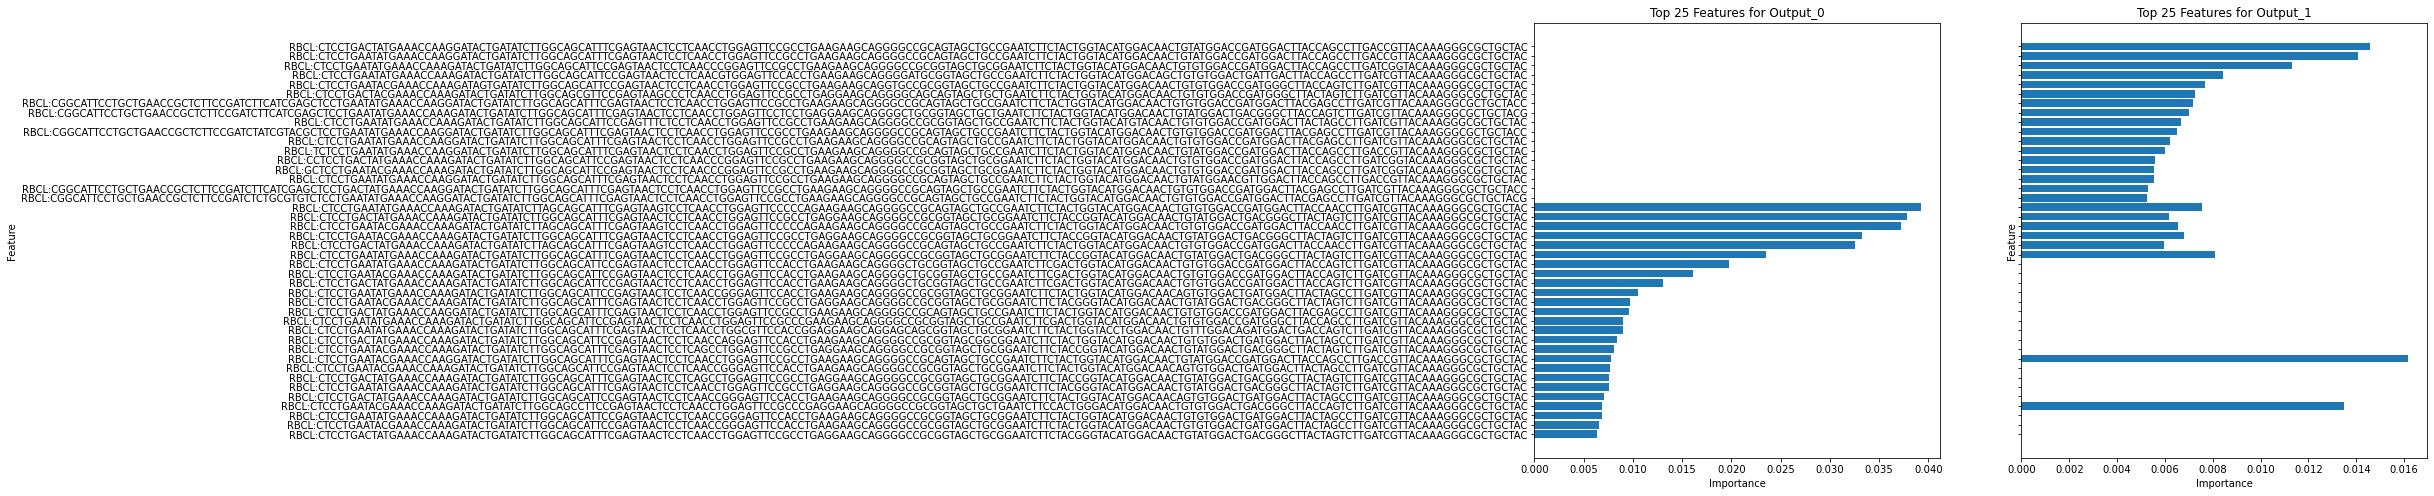

In [11]:
import matplotlib.pyplot as plt

# Create subplots for 2 outputs
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

for i, (output_name, importances) in enumerate(top_features.items()):
    ax = axes[i]
    importances = importances.sort_values()  # So the bars go from low to high
    ax.barh(importances.index, importances.values)
    ax.set_title(f"Top {top_n} Features for {output_name}")
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()


In [12]:
# Union of all top features
all_top_features = set()
for feat_series in top_features.values():
    all_top_features.update(feat_series.index)

print(f"Total unique features to BLAST: {len(all_top_features)}")


Total unique features to BLAST: 42


In [13]:
clean_top_features = {name.replace("RBCL:", "") for name in all_top_features}


In [14]:
# Make a list with unique labels
labeled_seqs = [
    (f"Feature_{i+1}", seq) for i, seq in enumerate(clean_top_features)
]

print(labeled_seqs)

[('Feature_1', 'CTCCTGAATATGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACGTGGAGTTCCACCTGAAGAAGCAGGGGATGCGGTAGCTGCCGAATCTTCTACTGGTACATGGACAGCTGTGTGGACTGATTGACTTACCAGCCTTGATCGTTACAAAGGGCGCTGCTAC'), ('Feature_2', 'CGGCATTCCTGCTGAACCGCTCTTCCGATCTTCATCGAGCTCCTGAATATGAAACCAAGGATACTGATATCTTGGCAGCATTTCGAGTAACTCCTCAACCTGGAGTTCCGCCTGAAGAAGCAGGGGCCGCAGTAGCTGCCGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGACTTACGAGCCTTGATCGTTACAAAGGGCGCTGCTACC'), ('Feature_3', 'CTCCTGAATACGAAACCAAAGATAGTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCTGGAGTTCCGCCTGAAGAAGCAGGTGCCGCGGTAGCTGCCGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGGCTTACCAGTCTTGATCGTTACAAAGGGCGCTGCTAC'), ('Feature_4', 'CTCCTGACTATGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCGGGAGTTCCACCTGAAGAAGCAGGGGCCGCGGTAGCTGCGGAATCTTCTACTGGTACATGGACAACAGTGTGGACTGATGGACTTACTAGCCTTGATCGTTACAAAGGGCGCTGCTAC'), ('Feature_5', 'CTCCTGAATATGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTTTCTCCTCAACCTGGAGTTCCGCCTGAAGAAGCAGGGGCCGCGGTAGCTGCCGAATCTTCTACTGGTACATGTACAACTGTGTGGACCGATGGACTTACTAGC

In [15]:
pwd

'c:\\Users\\rah10\\University of Oregon Dropbox\\Rebecca Hayes\\pollenGeolocation\\raw'

In [16]:
from Bio.Blast import NCBIWWW, NCBIXML
import pandas as pd
import time

results = []

for i, (label, seq) in enumerate(labeled_seqs):
    print(f"BLASTing {i+1}/{len(labeled_seqs)}: {label}...")
    
    try:
        result_handle = NCBIWWW.qblast(
            program="blastn",
            database="nt",
            sequence=seq,
            hitlist_size=10,   # limit top hits
            expect=0.001,      # stricter cutoff
            filter="L"         # mask low-complexity
        )
        
        # Save raw result for reproducibility
        with open(f"../data/raw/blast_xmls_top_feats/blast_result_{label}.xml", "w") as out_handle:
            out_handle.write(result_handle.read())
        result_handle.close()

        # Reopen to parse
        with open(f"../data/raw/blast_xmls_top_feats/blast_result_{label}.xml") as result_handle:
            blast_record = NCBIXML.read(result_handle)

        top_hit = None
        for alignment in blast_record.alignments:
            for hsp in alignment.hsps:
                top_hit = {
                    "Label": label,
                    "TopHitTitle": alignment.title,
                    "Evalue": hsp.expect,
                    "Identity": hsp.identities / alignment.length
                }
                break
            break

        if top_hit:
            results.append(top_hit)
        else:
            results.append({
                "Label": label,
                "TopHitTitle": "No hit",
                "Evalue": None,
                "Identity": None
            })

    except Exception as e:
        print(f"Error with {label}: {e}")
        results.append({
            "Label": label,
            "TopHitTitle": "Error",
            "Evalue": None,
            "Identity": None
        })

    time.sleep(2)  # Polite pause for NCBI

# Convert to DataFrame
blast_hits_df = pd.DataFrame(results)
print(blast_hits_df)

# Save hits to CSV
blast_hits_df.to_csv("../data/raw/raw_blast_hits_summary.csv", index=False)
print("Saved hits summary to blast_hits_summary.csv")


BLASTing 1/42: Feature_1...
BLASTing 2/42: Feature_2...
BLASTing 3/42: Feature_3...
BLASTing 4/42: Feature_4...
BLASTing 5/42: Feature_5...
BLASTing 6/42: Feature_6...
BLASTing 7/42: Feature_7...
BLASTing 8/42: Feature_8...
BLASTing 9/42: Feature_9...
BLASTing 10/42: Feature_10...
BLASTing 11/42: Feature_11...
BLASTing 12/42: Feature_12...
BLASTing 13/42: Feature_13...
BLASTing 14/42: Feature_14...
BLASTing 15/42: Feature_15...
BLASTing 16/42: Feature_16...
BLASTing 17/42: Feature_17...
BLASTing 18/42: Feature_18...
BLASTing 19/42: Feature_19...
BLASTing 20/42: Feature_20...
BLASTing 21/42: Feature_21...
BLASTing 22/42: Feature_22...
BLASTing 23/42: Feature_23...
BLASTing 24/42: Feature_24...
BLASTing 25/42: Feature_25...
BLASTing 26/42: Feature_26...
BLASTing 27/42: Feature_27...
BLASTing 28/42: Feature_28...
BLASTing 29/42: Feature_29...
BLASTing 30/42: Feature_30...
BLASTing 31/42: Feature_31...
BLASTing 32/42: Feature_32...
BLASTing 33/42: Feature_33...
BLASTing 34/42: Feature_34..

In [17]:
blast_hits_df

,Label,TopHitTitle,Evalue,Identity
0,Feature_1,gi|1243024465|gb|MF349293.1| Viburnum prunifol...,4.749320e-76,0.312839
1,Feature_2,gi|685847077|gb|KJ841310.1| Conyza canadensis ...,1.864980e-82,0.317291
2,Feature_3,gi|2459374538|ref|NC_072259.1| Albizia kalkora...,9.168340e-79,0.000992
3,Feature_4,gi|2416168325|gb|OP711146.1| Rhododendron sims...,1.769910e-81,0.779736
4,Feature_5,gi|340510861|gb|HM849781.1| Antirrhinum majus ...,9.168340e-79,0.128393
5,Feature_6,gi|2860879658|gb|OQ148752.1| Carya sinensis is...,3.898480e-77,0.001080
6,Feature_7,gi|1184798478|gb|KX678230.1| Phacelia heteroph...,1.769910e-81,0.320652
7,Feature_8,gi|2496528119|gb|ON341444.1| Helianthus angust...,6.221390e-81,0.318264
8,Feature_9,gi|2510044158|gb|OQ139470.1| Polyscias frutico...,7.525830e-80,0.339768
9,Feature_10,gi|2315905970|gb|ON950985.1| Stachys cf. gland...,1.769910e-81,0.233113


In [19]:
blast_hits_df.TopHitTitle[0]

'gi|1243024465|gb|MF349293.1| Viburnum prunifolium isolate AD0EE90 ribulose-1,5-bisphosphate carboxylase/oxygenase large subunit (rbcL) gene, partial cds; chloroplast'

In [20]:
def extract_species(title):
    # Remove GI info if any
    parts = title.split('|')
    if len(parts) > 2:
        after_pipe = parts[-1]  # grab last section
    else:
        after_pipe = title

    # Get first two words
    words = after_pipe.strip().split()
    if len(words) >= 2:
        return f"{words[0]} {words[1]}"
    else:
        return None

blast_hits_df["Species"] = blast_hits_df["TopHitTitle"].apply(extract_species)


In [21]:
blast_hits_df

,Label,TopHitTitle,Evalue,Identity,Species
0,Feature_1,gi|1243024465|gb|MF349293.1| Viburnum prunifol...,4.749320e-76,0.312839,Viburnum prunifolium
1,Feature_2,gi|685847077|gb|KJ841310.1| Conyza canadensis ...,1.864980e-82,0.317291,Conyza canadensis
2,Feature_3,gi|2459374538|ref|NC_072259.1| Albizia kalkora...,9.168340e-79,0.000992,Albizia kalkora
3,Feature_4,gi|2416168325|gb|OP711146.1| Rhododendron sims...,1.769910e-81,0.779736,Rhododendron simsii
4,Feature_5,gi|340510861|gb|HM849781.1| Antirrhinum majus ...,9.168340e-79,0.128393,Antirrhinum majus
5,Feature_6,gi|2860879658|gb|OQ148752.1| Carya sinensis is...,3.898480e-77,0.001080,Carya sinensis
6,Feature_7,gi|1184798478|gb|KX678230.1| Phacelia heteroph...,1.769910e-81,0.320652,Phacelia heterophylla
7,Feature_8,gi|2496528119|gb|ON341444.1| Helianthus angust...,6.221390e-81,0.318264,Helianthus angustifolius
8,Feature_9,gi|2510044158|gb|OQ139470.1| Polyscias frutico...,7.525830e-80,0.339768,Polyscias fruticosa
9,Feature_10,gi|2315905970|gb|ON950985.1| Stachys cf. gland...,1.769910e-81,0.233113,Stachys cf.


In [54]:
# Suppose your blast_hits_df has:
#   Label          Species
#   RBCL:ASV1      Arabidopsis thaliana
#   RBCL:ASV2      Poa annua
#   ...

# Or, if you used generic Feature_1 labels, keep your own mapping of ASV -> Feature_X

species_map = blast_hits_df[["Label", "Species"]].set_index("Label")


In [62]:
# Map the index (which is feature names)
importance_df["Species"] = importance_df.index.map(species_map["Species"])

# Fill any missing with the original ID for clarity
importance_df["Label"] = [
    f"{species if pd.notnull(species) else feat}"
    for feat, species in zip(importance_df.index, importance_df["Species"])
]
importance_df = importance_df.iloc[:,:-2]
importance_df

,Latitude,Longitude,Species,Label
RBCL:ACCTCCTGAATATGAAACCAAGGATTCCGATATTTTGGCAGCATTTCGAGGAACTCCTCAACTTGGAGTTCCACCTGAATAAGCAAGGCCGCAGTAGCTGTCAAATCTTCTACTAGTACATGAACAATTGTGTAGACCAATGAACTTACGAGCGTTGATTGTTACAAAGGGCGCTGCTAC,0.000000,0.000000,NaN,RBCL:ACCTCCTGAATATGAAACCAAGGATTCCGATATTTTGGCAG...
RBCL:ACTCCTGAATACGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCCGGAGTTCCGCCTGAAGAAGCAGGGGCCGCGGTAGCTGCGGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGACTTACCAGCCTTGATCGGTACAAAGGGCGCTGCTAC,0.001082,0.003156,NaN,RBCL:ACTCCTGAATACGAAACCAAAGATACTGATATCTTGGCAGC...
RBCL:ACTCCTGAATACGAAACCAAGGATACTGATATCTTGGCAGCATTTCGAGTAACTCCTCAACCTGGAGTTCCGCCTGAAGAAGCAGGGGCCGCAGTAGCTGCCGAATCTTCTACTGGTACATGGACAACTGTATGGACCGATGGACTTACCAGCCTTGACCGTTACAAAGGGCGCTGCTAC,0.000210,0.000959,NaN,RBCL:ACTCCTGAATACGAAACCAAGGATACTGATATCTTGGCAGC...
RBCL:ACTCCTGAATATGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCCGGAGTTCCGCCTGAAGAAGCAGGGGCCGCGGTAGCTGCGGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGACTTACCAGCCTTGATCGGTACAAAGGGCGCTGCTAC,0.001168,0.002822,NaN,RBCL:ACTCCTGAATATGAAACCAAAGATACTGATATCTTGGCAGC...
RBCL:ACTCCTGAATATGAAACCAAAGATACTGATATCTTGGCAGCATTCCGAGTAACTCCTCAACCCGGAGTTCCGCCTGAAGAAGCAGGGGCCGCGGTAGCTGCGGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGACTTACCAGCCTTGATCGTTACAAAGGGCGCTGCTAC,0.000632,0.001643,NaN,RBCL:ACTCCTGAATATGAAACCAAAGATACTGATATCTTGGCAGC...
...,...,...,...,...
RBCL:TCTCCTGACTATGAAACCAAGGATACTGATATTTTGGCAGCATTTCGAGTAACTCCTCAACCTGGAGTTCCACCGGAAGAAGCAGGGGCCGCAGTAGCTGCCGAATCTTCGACTGGTACATGGACAACTGTGTGGACCGATGGACTTACGAGCCTTGATCGTTACAAAGGGCGCTGCTAC,0.000216,0.000608,NaN,RBCL:TCTCCTGACTATGAAACCAAGGATACTGATATTTTGGCAGC...
RBCL:TCTCCTGACTATGAAACCAAGGATACTGATATTTTGGCAGCATTTCGAGTAACTCCTCAACCTGGAGTTCCGCCTGAAGAAGCAGGGGCCGCAGTAGCTGCCGAATCTTCTACTGGTACATGGACAACTGTGTGGACCGATGGACTTACGAGCCTTGATCGTTACAAAGGGCGCTGCTAC,0.000432,0.001408,NaN,RBCL:TCTCCTGACTATGAAACCAAGGATACTGATATTTTGGCAGC...
RBCL:TCTCCTGACTATGAAACCAAGGATACTTATATCTTGGCAGCATTTCGAGTAACTCCTCAACTTGGAGTTCCGCCTGAAGAAGCAGGGGCCGCAGTAGCTGTCGAATCTTCTACTGGTACGTGGACAACTGTATGGACCGATGGACTTACCAGCCTTGACCGTTACAAAGGGCGCTGCTAC,0.000024,0.000096,NaN,RBCL:TCTCCTGACTATGAAACCAAGGATACTTATATCTTGGCAGC...
RBCL:TCTCTCTAGACCTCCTGAATATGAAACCAAAGATACTGATATCTTGGTAGCATTCCGGGTAACTCCTCAACCTGGAGTTCTGCCTAATGGGTCGTGGTAGCTGCCGAATCTTCTACTGCATGGACAACTGTGTGGACTGACGGACTTACTAGACTTGATTGTTACAAAGGGCGCTGCTAC,0.000000,0.000000,NaN,RBCL:TCTCTCTAGACCTCCTGAATATGAAACCAAAGATACTGATA...


In [63]:
top_features = {}

for col in importance_df.columns[:-2]:  # exclude the Species & Label cols
    top = (
        importance_df[col]
        .sort_values(ascending=False)
        .head(top_n)
    )
    labels = importance_df.loc[top.index, "Label"]
    top.index = labels  # Use species names instead of ASV IDs
    top_features[col] = top


In [64]:
# Get a DataFrame of original features
features_df = pd.DataFrame({
    "FeatureID": importance_df.index,
})

# Remove 'RBCL:' prefix to get just the sequence
features_df["Sequence"] = features_df["FeatureID"].str.replace("RBCL:", "")
#features_df


In [65]:
labeled_df = pd.DataFrame(labeled_seqs, columns=["Label", "Sequence"])
#labeled_df

In [66]:
# Merge to add the Feature_# label
features_labeled = features_df.merge(labeled_df, on="Sequence", how="left")

# Merge to add Species from your BLAST hits
features_labeled = features_labeled.merge(
    blast_hits_df[["Label", "Species"]],
    on="Label",
    how="left"
)
#features_labeled

In [67]:
species_lookup = features_labeled.set_index("FeatureID")["Species"]

importance_df["Species"] = importance_df.index.map(species_lookup)

# Fallback to raw FeatureID if Species missing
importance_df["Label"] = importance_df.apply(
    lambda row: row["Species"] if pd.notnull(row["Species"]) else row.name,
    axis=1
)
# Rename the output columns
importance_df = importance_df.rename(columns={
    "Output_0": "Latitude",
    "Output_1": "Longitude"
})
importance_df.columns


Index(['Latitude', 'Longitude', 'Species', 'Label'], dtype='object')

In [70]:
top_features = {}
for col in importance_df.columns[:-2]:  # exclude Species, Label cols
    top = importance_df[col].sort_values(ascending=False).head(25)
    labels = importance_df.loc[top.index, "Label"]
    top.index = labels
    top_features[col] = top


In [71]:
print(top_features.keys())


dict_keys(['Latitude', 'Longitude'])


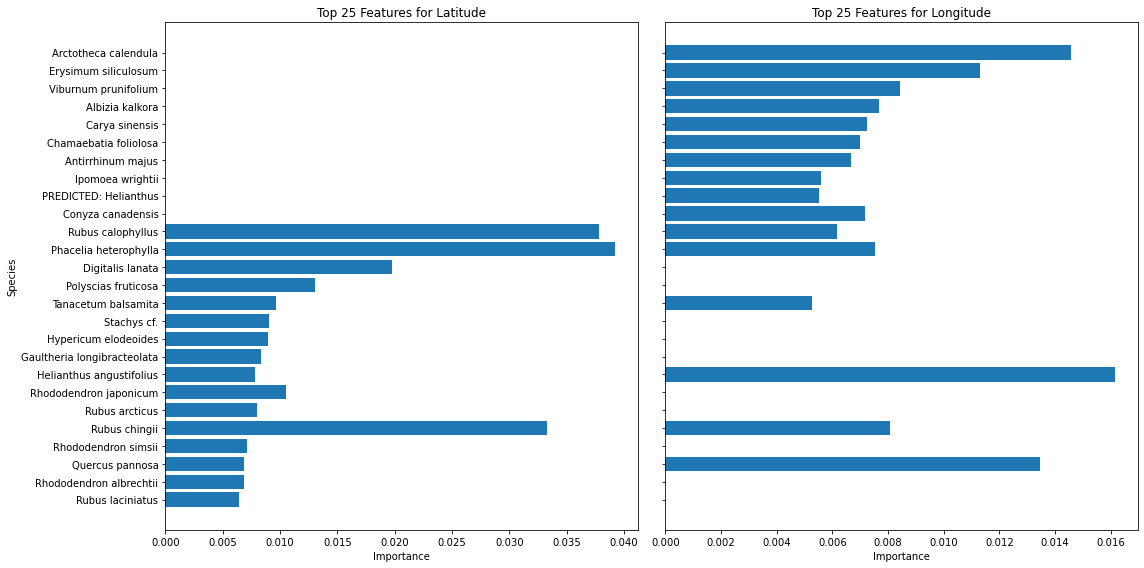

In [72]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(top_features), figsize=(16, 8), sharey=True)

for i, (output_name, importances) in enumerate(top_features.items()):
    ax = axes[i]
    importances = importances.sort_values()
    ax.barh(importances.index, importances.values)
    ax.set_title(f"Top 25 Features for {output_name}")
    ax.set_xlabel("Importance")
    if i == 0:
        ax.set_ylabel("Species")
    else:
        ax.set_ylabel("")

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score as acc
names = np.load('X_cols.npy', allow_pickle = True)
#reg= ExtraTreesRegressor()
rf.fit(X_train,y_train)
importance = rf.feature_importances_
#print(np.column_stack((names, importance)))
feat_importances = pd.Series(rf.feature_importances_, index=names)
print('Most Important Features')
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'X_cols.npy'

In [17]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score as acc
#names = np.load('X_cols.npy', allow_pickle = True)
#reg= ExtraTreesRegressor()
#rf.fit(X_train,y_train)
importance = rf.feature_importances_
#print(np.column_stack((names, importance)))
feat_importances = pd.Series(rf.feature_importances_, index=names)
print('Most Important Features')
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

AttributeError: 'MultiOutputRegressor' object has no attribute 'feature_importances_'

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score as acc
names = np.load('X_cols.npy', allow_pickle = True)
#reg= ExtraTreesRegressor()
rf.fit(X_train,y_train)
importance = rf.feature_importances_
#print(np.column_stack((names, importance)))
feat_importances = pd.Series(rf.feature_importances_, index=names)
print('Most Important Features')
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

In [ ]:
import shap
import numpy as np

# 1. Extract your MultiOutputRegressor
# Example:
# rf_model = rf_result["estimator"]

# 2. Loop over outputs (e.g., lat, lon)
shap_values_list = []

for i, estimator in enumerate(rf.estimators_):
    explainer = shap.TreeExplainer(estimator)
    shap_values = explainer.shap_values(X_test)
    shap_values_list.append(shap_values)

# 3. Average absolute SHAP values if you want a single importance score
mean_shap = np.mean(np.abs(np.stack(shap_values_list)), axis=0)

# 4. Wrap in DataFrame
shap_df = pd.DataFrame(mean_shap, columns=X_cols)
shap_df["project"] = project_test

# 5. Group by project
project_feature_importance = (
    shap_df.groupby("project")
    .agg(lambda x: np.mean(np.abs(x)))
    .transpose()
)

print(project_feature_importance)
